In [1]:
import sys

sys.path.append('../src/')
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pysindy as ps
from libselection.utils import *
from libselection import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl

# Data Generation

$$
\begin{dcases}
    \dot{x} = \mu x -\omega y -x(x^2+y^2), \\
    \dot{y} = \omega x + \mu y - y(x^2+y^2).
\end{dcases}
$$

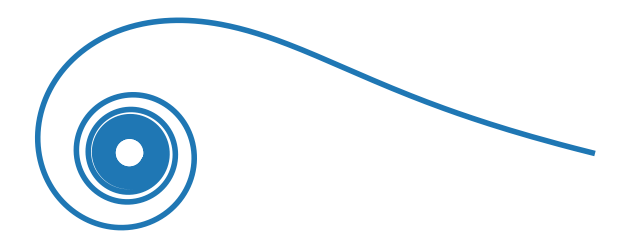

In [ ]:
# Hopf system parameters
mu = -1e-5
# mu = 0
w = 1

# Hopf system equations
def hopf(t, state, mu, w):
    x, y = state
    dxdt = mu*x - w*y - x*(x**2 + y**2)
    dydt = w*x + mu*y - y*(x**2 + y**2)
    return [dxdt, dydt]


# Time range for simulation
dt = 0.01
t = np.arange(0, 100 + 2*dt, dt)
t_train = t
# Initial condition
initial_state = [5, 0]
integrator_keywords = {}
integrator_keywords["rtol"] = 1e-12
integrator_keywords["method"] = "RK45"
integrator_keywords["atol"] = 1e-12
# Solve the Hopf system
hopf_data = solve_ivp(hopf, (t[0], t[-1]), initial_state, t_eval=t_train, args=(mu, w), **integrator_keywords).y.T

# # Normalize the data for simplicity
# hopf_data = hopf_data / np.max(np.abs(hopf_data), axis=0)

# Plot the Hopf attractor
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(hopf_data[:, 0], hopf_data[:, 1], lw=4)
ax.set_axis_off()
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('Figs/hopf_attractor.png', dpi=1200)
plt.show()



In [ ]:
x_train = hopf_data
t_train = t
var_names = ['x', 'y']

library_gen = ps.PolynomialLibrary(degree=3) #+ ps.FourierLibrary(n_frequencies=2)
D = np.array(library_gen.fit_transform(x_train))
_, No_D = D.shape
name_tag = np.array(library_gen.get_feature_names(var_names))
x_dot = non_uniform_diff(x_train, t_train)